# Airbnb Multi-City Analysis — Notebook 04: Hypothesis Testing

**Author:** Data Analyst Team  
**Project:** Airbnb Multi-City Data Analysis  
**Notebook:** 04 - Hypothesis Testing  
**Environment:** Python + Jupyter + uv  
**Version:** 1.0  
**Last update:** 2026-04-16

---

## Business Context

The exploratory analysis identified several pricing patterns across cities, room types, reviews, availability, and outliers.

However, visual patterns alone are not enough for decision-making.  
This notebook applies statistical hypothesis testing to determine whether the observed differences are statistically meaningful.

## Notebook Objective

The objective of this notebook is to validate key business hypotheses identified during the EDA stage using statistical methods.

This notebook focuses on:
- testing whether prices differ significantly across cities,
- testing whether room type has a significant impact on price,
- evaluating whether reviewed and non-reviewed listings differ in price,
- assessing whether availability groups show different pricing behavior,
- and translating statistical results into business conclusions.

## Why This Notebook Matters

EDA helps identify patterns.  
Hypothesis testing helps validate whether those patterns are strong enough to support business decisions and dashboard storytelling.

The output of this notebook will support:
- Power BI dashboard design,
- executive insights,
- segmentation strategy,
- and future modeling decisions.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind, spearmanr, kruskal

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("data/processed/airbnb_clean.csv", parse_dates=["last_review"])
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city,log_price,has_reviews,availability_group,review_intensity
0,6369,"Rooftop terrace room , ensuite bathroom",13660,Simon,Chamartín,Hispanoamérica,40.45724,-3.67688,Private room,60,...,78,2020-09-20,0.58,1.0,180.0,Madrid,4.110874,1,Medium,High
1,21853,Bright and airy room,83531,Abdel,Latina,Cármenes,40.40381,-3.74130,Private room,31,...,33,2018-07-15,0.42,2.0,364.0,Madrid,3.465736,1,High,High
2,23001,Apartmento Arganzuela- Madrid Rio,82175,Jesus,Arganzuela,Legazpi,40.38840,-3.69511,Entire home/apt,50,...,0,NaT,0.00,7.0,1.0,Madrid,3.931826,0,Low,Low
3,24805,Gran Via Studio Madrid,346366726,A,Centro,Universidad,40.42183,-3.70529,Entire home/apt,92,...,10,2020-03-01,0.13,1.0,72.0,Madrid,4.532599,1,Medium,Medium
4,26825,Single Room whith private Bathroom,114340,Agustina,Arganzuela,Legazpi,40.38975,-3.69018,Private room,26,...,149,2020-03-12,1.12,1.0,365.0,Madrid,3.295837,1,High,High


In [3]:
df = pd.read_csv("../data/processed/airbnb_powerbi.csv", parse_dates=["last_review"])
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city,has_reviews,currency,price_eur,log_price_view
0,6369,"Rooftop terrace room , ensuite bathroom",13660,Simon,Chamartín,Hispanoamérica,40.45724,-3.67688,private room,60,...,78,2020-09-20,0.58,1.0,180.0,Madrid,1,EUR,60.0,4.110874
1,21853,Bright and airy room,83531,Abdel,Latina,Cármenes,40.40381,-3.74130,private room,31,...,33,2018-07-15,0.42,2.0,364.0,Madrid,1,EUR,31.0,3.465736
2,23001,Apartmento Arganzuela- Madrid Rio,82175,Jesus,Arganzuela,Legazpi,40.38840,-3.69511,entire home/apt,50,...,0,NaT,0.00,7.0,1.0,Madrid,0,EUR,50.0,3.931826
3,24805,Gran Via Studio Madrid,346366726,A,Centro,Universidad,40.42183,-3.70529,entire home/apt,92,...,10,2020-03-01,0.13,1.0,72.0,Madrid,1,EUR,92.0,4.532599
4,26825,Single Room whith private Bathroom,114340,Agustina,Arganzuela,Legazpi,40.38975,-3.69018,private room,26,...,149,2020-03-12,1.12,1.0,365.0,Madrid,1,EUR,26.0,3.295837


## Hypothesis 1: Price vs Demand (Proxy: Number of Reviews)

H0: There is no monotonic relationship between price and number of reviews  
H1: There is a monotonic relationship between price and number of reviews

In [4]:
corr, p_value = spearmanr(df["price_eur"], df["number_of_reviews"])

print("Correlation:", round(corr, 3))
print("p-value:", p_value)

Correlation: -0.078
p-value: 1.0728805801462464e-295


Conclusion:
Although the relationship between price and demand is statistically significant,
the effect size is extremely small and not practically meaningful.

## Hypothesis 2: Large Hosts vs Small Hosts

We define large hosts as those with multiple listings.

In [5]:
# Define host type
df["host_type"] = np.where(
    df["calculated_host_listings_count"] > 1,
    "Multi-listing host",
    "Single-listing host"
)

# Create groups using the official price variable
multi_host_prices = df[df["host_type"] == "Multi-listing host"]["price_eur"].dropna()
single_host_prices = df[df["host_type"] == "Single-listing host"]["price_eur"].dropna()

# Welch's t-test
stat, p_value = ttest_ind(
    multi_host_prices,
    single_host_prices,
    equal_var=False
)

print("Welch's t-test")
print("-" * 30)
print(f"Statistic: {stat:.4f}")
print(f"p-value: {p_value:.5e}")

print("\nGroup comparison")
print("-" * 30)
print(f"Multi-listing host mean: {multi_host_prices.mean():.2f}")
print(f"Single-listing host mean: {single_host_prices.mean():.2f}")
print(f"Multi-listing host median: {multi_host_prices.median():.2f}")
print(f"Single-listing host median: {single_host_prices.median():.2f}")

Welch's t-test
------------------------------
Statistic: 19.2951
p-value: 7.43829e-83

Group comparison
------------------------------
Multi-listing host mean: 146.29
Single-listing host mean: 122.42
Multi-listing host median: 90.00
Single-listing host median: 84.00


In [6]:
from scipy.stats import mannwhitneyu

stat_u, p_value_u = mannwhitneyu(
    multi_host_prices,
    single_host_prices,
    alternative="two-sided"
)

print("Mann-Whitney U test")
print("-" * 30)
print(f"Statistic: {stat_u:.4f}")
print(f"p-value: {p_value_u:.5e}")

Mann-Whitney U test
------------------------------
Statistic: 6113765316.5000
p-value: 3.37718e-71


A significant difference suggests that professional hosts behave differently in pricing strategy.

## Hypothesis 3: Availability vs Price

**H0:** There is no monotonic relationship between listing availability and price.  
**H1:** There is a monotonic relationship between listing availability and price.

Availability is measured using `availability_365`, which represents the number of days a listing is available during the year. Price is measured using `price_eur`, the standardized price in euros.

In [8]:
df_clean = df.dropna(subset=["availability_365", "price_eur"])

corr, p_value = spearmanr(
    df_clean["availability_365"],
    df_clean["price_eur"]
)

print("Correlation:", round(corr, 3))
print("p-value:", p_value)

Correlation: 0.082
p-value: 1.571476895867842e-305


Availability has a statistically significant but practically negligible positive relationship with price.

## Hypothesis 4: Listings with vs without Reviews

**H0:** There is no difference in price between listings with reviews and listings without reviews.  
**H1:** There is a difference in price between listings with reviews and listings without reviews.

The variable `has_reviews` is used as a proxy:
- 1 → listing has reviews
- 0 → listing has no reviews

In [9]:
group1 = df[df["has_reviews"] == 1]["price_eur"]
group2 = df[df["has_reviews"] == 0]["price_eur"]

stat, p_value = ttest_ind(group1, group2, equal_var=False)

print("p-value:", p_value)

p-value: 4.021845775657372e-219


there is strong statistical evidence that the difference is not due to random noise

## Hypothesis 5: Neighbourhood vs Price

**H0:** There is no difference in price distributions across neighbourhoods.  
**H1:** There is a difference in price distributions across neighbourhoods.

We test whether neighbourhood location is associated with listing price. Since prices are skewed and contain outliers, we use the Kruskal-Wallis test to compare price distributions across neighbourhoods.

In [22]:
neigh_groups = [group["price_eur"].values 
                for name, group in df.groupby("neighbourhood") 
                if len(group) > 75
                ]
stat, p_value = kruskal(*neigh_groups)
print("p-value:", p_value)

p-value: 0.0


In [26]:
top_neighbourhoods = (
    df
    .groupby(["city", "neighbourhood"])
    .agg(
        listings=("price_eur", "size"),
        median_price=("price_eur", "median"),
        mean_price=("price_eur", "mean"),
        p90_price=("price_eur", lambda x: x.quantile(0.9))
    )
    .reset_index()
    .query("listings >= 150")
    .sort_values(["city", "median_price"], ascending=[True, False])
)

top_neighbourhoods.head(20)

,city,neighbourhood,listings,median_price,mean_price,p90_price
6,London,City of London,465,172.500,219.390323,345.00
19,London,Kensington and Chelsea,6018,172.500,249.858234,460.00
32,London,Westminster,9586,161.000,248.691519,454.25
5,London,Camden,5971,115.000,166.093242,287.50
12,London,Hammersmith and Fulham,4210,109.250,151.373052,287.50
18,London,Islington,5108,103.500,129.519988,230.00
26,London,Richmond upon Thames,1200,103.500,144.639333,287.50
31,London,Wandsworth,4272,97.750,134.790929,258.52
27,London,Southwark,4891,92.000,125.676590,218.50
11,London,Hackney,6275,86.250,110.130231,187.45


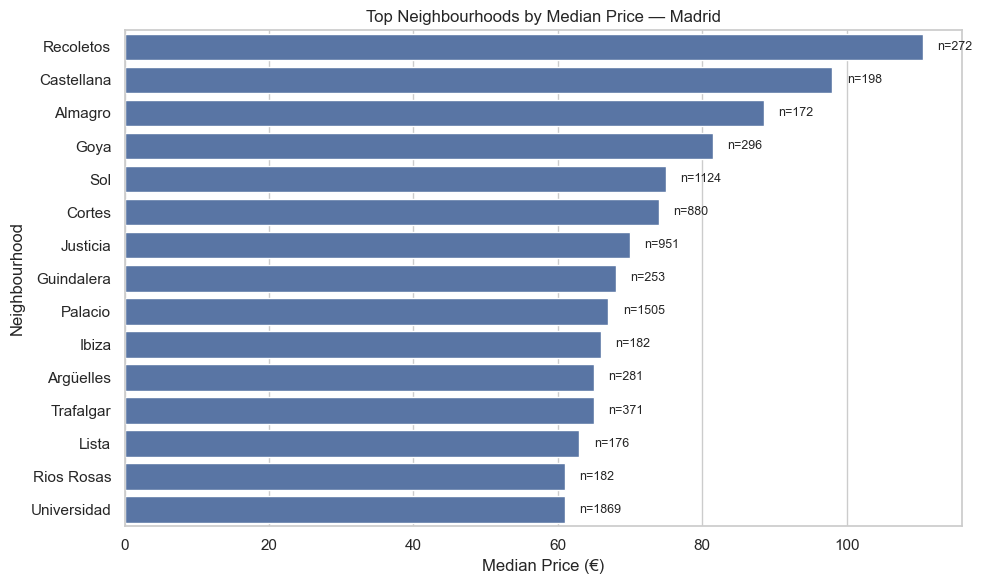

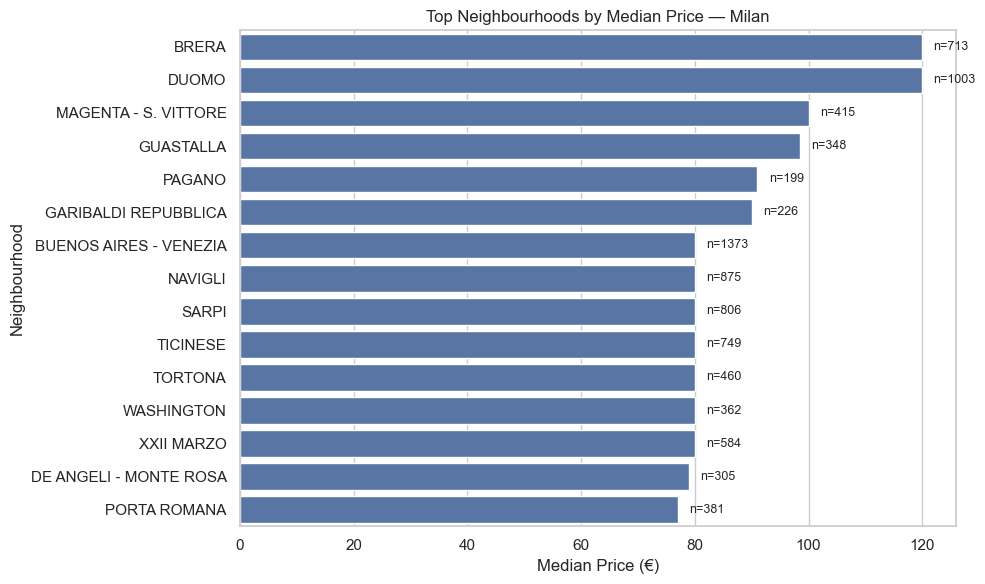

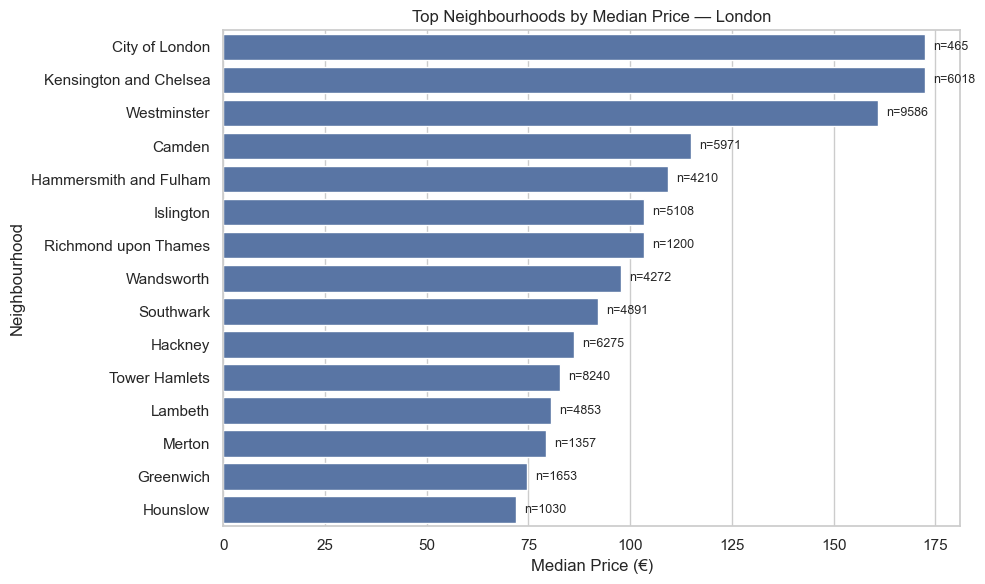

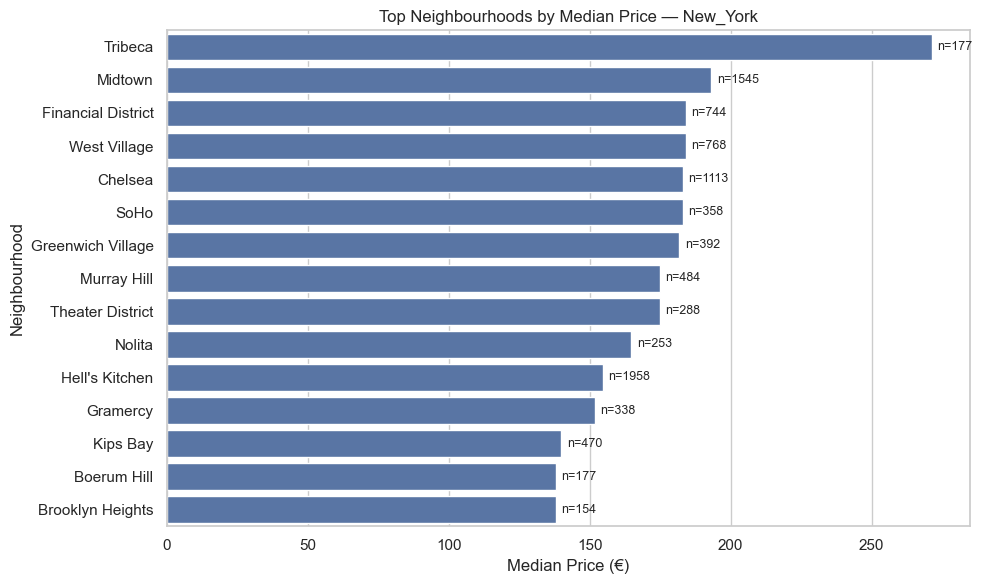

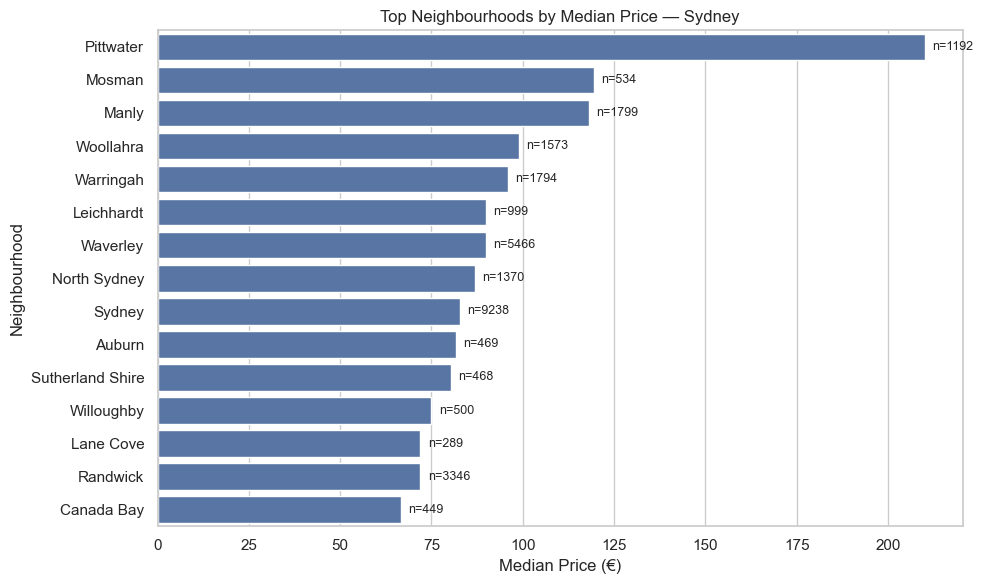

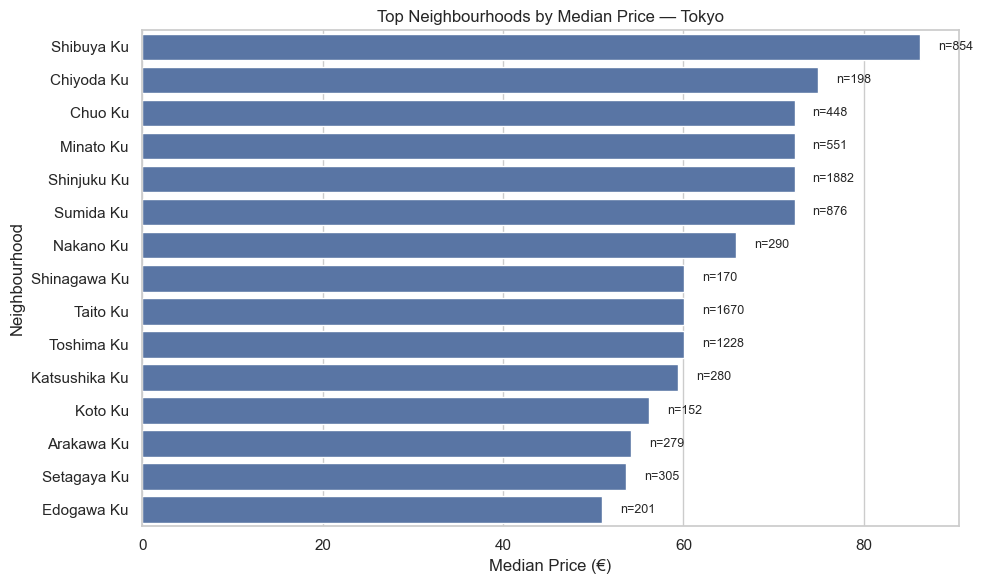

In [27]:
for city in df["city"].unique():
    
    city_data = (
        top_neighbourhoods[top_neighbourhoods["city"] == city]
        .sort_values("median_price", ascending=False)
        .head(15)
    )

    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        data=city_data,
        x="median_price",
        y="neighbourhood"
    )

    for i, row in city_data.reset_index(drop=True).iterrows():
        ax.text(
            row["median_price"] + 2,
            i,
            f"n={int(row['listings'])}",
            va="center",
            fontsize=9
        )

    plt.title(f"Top Neighbourhoods by Median Price — {city}")
    plt.xlabel("Median Price (€)")
    plt.ylabel("Neighbourhood")

    plt.tight_layout()
    plt.show()

Neighbourhood has a statistically significant relationship with price, but the value of this analysis comes from the ranked neighbourhood summaries, not from the p-value alone.

## Final Conclusions

This analysis validates several key findings about Airbnb pricing dynamics:

- Price shows a statistically significant but weak negative relationship with demand (proxied by number of reviews), indicating that cheaper listings tend to receive slightly more engagement, although price alone is not a strong demand driver.

- Multi-listing hosts charge higher prices on average compared to single-listing hosts, suggesting a more professionalized pricing strategy.

- Availability has a weak positive relationship with price, indicating that higher-priced listings tend to remain available longer, possibly due to lower booking frequency.

- Listings without reviews show statistically different pricing behavior, often associated with either new or underperforming listings.

- Location is a major determinant of price, with strong variation within cities.

- Neighbourhood-level analysis reveals that price differences are primarily driven by intra-city location rather than differences between cities.

- Two distinct market patterns emerge:
  - Premium residential areas with higher prices and lower listing density
  - High-demand central areas with high supply and moderated pricing

## Dashboard Implications

The validated insights suggest the following dashboard structure:

### Pricing Analysis
- Median price by room type
- Price distribution (log scale)
- Premium segment (p90 price)

### Location Analysis
- Price by city and neighbourhood
- Top neighbourhoods by price (with listing volume)
- Geographic distribution (map view)

### Host Segmentation
- Price comparison: multi-listing vs single hosts
- Distribution of host types across cities

### Supply vs Demand
- Availability vs price relationship
- Listings volume vs price by neighbourhood

### Demand Proxy
- Number of reviews vs price
- Segmentation of listings with vs without reviews